# Does the appearance-lag *trajectory* help detect SGA?  — from scratch

**What this notebook shows, end to end:**
1. How a fetus becomes a **path through the GRU-VAE latent space** (one 8-D code per gestational-age slot).
2. The interactive **3-D latent trajectory** coloured by outcome (the `lag_latent_trajectory_3d.html` figure).
3. The honest clinical test: **the lag *trajectory* — how appearance-maturity evolves relative to size over gestation — adds bootstrap-robust discrimination for SGA**, over a *matched* size-trajectory baseline. (The lag *endpoint* does not; only the trajectory does.)

Everything downstream of the latent is computed here. The latent itself is the **frozen canonical config-B GRU-VAE** trajectory (the recipe is documented in §2); loading it reproduces the exact numbers in the figures.

*Labels (SGA / birth percentile) are evaluation-only — they never enter the GRU-VAE training.*

## 0.  Setup

In [ ]:
import numpy as np, pandas as pd
from scipy.stats import pearsonr, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import HTML, display
np.random.seed(0)

IMG = "/Users/tiago/PythonProject/fgr-geometry/results/img_align"
OUTC_CSV = "/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv"
OUTC_XLS = "/Users/tiago/Documents/CiTUS/Dataset/Impact_longitudinal_161025_all_merged.xlsx"
print("libraries loaded")

libraries loaded


## 1.  Inputs

- `_merged_seq.npz` — per-fetus GA-ordered timeline `X (N, T, 44)` = `[5 biometry-z | 5 biometry-mask | 32 image-emb | img-mask | GA_norm]`, plus valid length `L`.
- `_lag_seq.npz` — per-slot **appearance-lag** scalar + mask (lag = image-clock predicted GA − true GA, averaged per GA-week).
- `_merged_labels.npz` — birth percentile (eval only).
- outcome tables — SGA subtypes (eval only).

We apply the canonical corrupt-biometry mask (`z < −10`, a physiologically-impossible missing-data sentinel).

In [ ]:
z = np.load(f"{IMG}/_merged_seq.npz", allow_pickle=True)
X = z["X"].astype(np.float32).copy(); L = z["L"]; fids = z["fids"]; F = int(z["F"])
# canonical mask: z < -10 -> value 0, mask bit 0 (treated as missing)
cor = X[:, :, :F] < -10
for j in range(F):
    cj = cor[:, :, j]; X[:, :, j][cj] = 0.0; X[:, :, F + j][cj] = 0.0
lz = np.load(f"{IMG}/_lag_seq.npz", allow_pickle=True)
lag_seq = lz["lag_seq"].astype(np.float32); lag_mask = lz["lag_mask"].astype(np.float32)
lab = np.load(f"{IMG}/_merged_labels.npz", allow_pickle=True)
birth = pd.Series(lab["birth"], index=lab["fids"]).reindex(fids).values.astype(float)
N, T, _ = X.shape; Lt = np.clip(L, 1, T)
GAch = X[:, :, -1]  # normalized (ga-6)/36
# per-fetus mean lag over real image visits
mean_lag = np.array([lag_seq[i, :Lt[i]][lag_mask[i, :Lt[i]] > 0].mean()
                     if (lag_mask[i, :Lt[i]] > 0).any() else np.nan for i in range(N)])
print(f"N={N} fetuses, max slots T={T}, biometry features F={F}")
print(f"fetuses with birth pct: {np.isfinite(birth).sum()}, with mean lag: {np.isfinite(mean_lag).sum()}")

N=908 fetuses, max slots T=12, biometry features F=5
fetuses with birth pct: 906, with mean lag: 883


## 2.  The canonical latent — how a fetus becomes a path

**Config-B GRU-VAE (frozen):** input per slot = `[5 biom-z | 5 biom-mask | lag | lag-mask | GA_norm]` (13-d). A GRU (hidden H=32) steps slot→slot; the per-slot hidden state → 8-D latent code. Trained unsupervised to reconstruct the fetus's visit-mean, β=0.1 KL, 250 epochs, Adam 1e-3. The mask bits tell the GRU which channels are real at each slot, so the sparse/misaligned biometry and image visits coexist on one timeline.

The array below is the frozen per-slot trajectory `traj (N, T, 8)` — **fetus = path through 8-D latent**. (Training recipe reproduced in `fgm_image/lag_in_gruvae_clean.py`.)

In [ ]:
traj = np.load(f"{IMG}/_lagB_traj_clean.npy")   # frozen canonical (N, T, 8)
Zend = np.array([traj[i, Lt[i] - 1] for i in range(N)])  # endpoint code per fetus
Zdim = traj.shape[2]
print("latent trajectory:", traj.shape)

# identify the axes data-drivenly (robust to VAE slot renumbering)
ok = np.isfinite(mean_lag) & np.isfinite(birth)
lag_axis  = int(np.argmax([abs(pearsonr(Zend[ok, d], mean_lag[ok])[0]) for d in range(Zdim)]))
size_axis = int(np.argmax([abs(pearsonr(Zend[ok, d], birth[ok])[0])    for d in range(Zdim)]))
print(f"lag axis  = z{lag_axis}  (|r| with mean lag = {abs(pearsonr(Zend[ok,lag_axis],mean_lag[ok])[0]):.3f})")
print(f"size axis = z{size_axis} (r with birth pct  = {pearsonr(Zend[ok,size_axis],birth[ok])[0]:+.3f})")

latent trajectory: (908, 12, 8)
lag axis  = z2  (|r| with mean lag = 0.855)
size axis = z6 (r with birth pct  = -0.470)


## 3.  Trajectory features on the lag axis

For each fetus we summarise **how it moves along the lag axis over gestation**:
- **velocity** — slope of lag-axis vs GA (per week)
- **net Δ** — lag-axis at last slot minus first
- **discordance slope** — slope of the lag axis *after removing its within-fetus dependence on the size axis* (the size-orthogonalized trajectory)
- **range** — span of the lag axis across the path

In [ ]:
def traj_feats(i):
    Lf = Lt[i]
    if Lf < 2: return [np.nan]*4
    g = GAch[i, :Lf]*36 + 6; la = traj[i, :Lf, lag_axis]; sa = traj[i, :Lf, size_axis]
    slope = np.polyfit(g, la, 1)[0]
    dlate = la[-1] - la[0]
    disc  = np.polyfit(g, la - np.polyval(np.polyfit(sa, la, 1), sa), 1)[0] if np.std(sa) > 1e-6 else np.nan
    return [slope, dlate, disc, la.max() - la.min()]
LAGT = np.array([traj_feats(i) for i in range(N)])          # (N,4) lag-trajectory features
def size_feats(i):
    Lf = Lt[i]
    if Lf < 2: return [np.nan]*3
    g = GAch[i, :Lf]*36 + 6; sa = traj[i, :Lf, size_axis]
    return [np.polyfit(g, sa, 1)[0], sa[-1]-sa[0], sa.max()-sa.min()]
SZT = np.array([size_feats(i) for i in range(N)])           # (N,3) size-trajectory features (fair baseline)
print("lag-traj features:", LAGT.shape, "| size-traj features (baseline):", SZT.shape)
print("coverage (all finite):", int(np.all(np.isfinite(LAGT),1).sum()), "fetuses")

lag-traj features: (908, 4) | size-traj features (baseline): (908, 3)
coverage (all finite): 908 fetuses


## 4.  Outcomes (evaluation only)

`SGA_prenCONFIRMED` (prenatally confirmed SGA) and `SGA_birth (<p10)` (birth percentile below 10) — decoded yes/no → 1/0.

In [ ]:
xl = pd.read_excel(OUTC_XLS, sheet_name="IMPACT_Final_All_V18")
xl["Cod"] = pd.to_numeric(xl["Cod"], errors="coerce")
xl = xl.dropna(subset=["Cod"]).drop_duplicates("Cod").set_index("Cod")
idx = pd.Index(fids)
def bincol(name):
    s = xl[name].reindex(idx).astype(str).str.strip().str.lower()
    return s.map({"yes":1,"no":0,"si":1,"1":1,"0":0}).astype(float).values
sga_conf = bincol("SGA_prenCONFIRMED")
sga_p10  = bincol("SGA_birth (<p10)")
print(f"SGA confirmed: n={int(np.isfinite(sga_conf).sum())}, positives={int(np.nansum(sga_conf))}")
print(f"SGA <p10     : n={int(np.isfinite(sga_p10).sum())}, positives={int(np.nansum(sga_p10))}")

SGA confirmed: n=906, positives=60
SGA <p10     : n=908, positives=156


## 5.  Does the lag trajectory help?  — the fair test

**The honest comparison.** The trajectory model adds features, so we must not compare it to a bare size endpoint. The fair baseline is **size endpoint + size-trajectory features**; the test model swaps in the **lag-trajectory features**. Any lift is then attributable to *lag dynamics*, not to "more features."

5-fold grouped-by-fetus AUC, with a 2000× bootstrap on the ΔAUC.

In [ ]:
size_ax = Zend[:, size_axis]
def oof_auc(feats, y):
    m = np.all(np.isfinite(feats),1) & np.isfinite(y)
    X_,Y_,g_ = feats[m], y[m].astype(int), fids[m]; p = np.zeros(len(Y_))
    for tr,te in GroupKFold(5).split(X_,Y_,g_):
        p[te] = LogisticRegression(max_iter=500).fit(X_[tr],Y_[tr]).predict_proba(X_[te])[:,1]
    return roc_auc_score(Y_,p), p, Y_, m

def fair_test(y, label):
    fb = np.column_stack([size_ax, SZT]); fl = np.column_stack([size_ax, LAGT])
    m = np.all(np.isfinite(fb),1) & np.all(np.isfinite(fl),1) & np.isfinite(y)
    Xb,Xl,Y,g = fb[m],fl[m],y[m].astype(int),fids[m]
    pb=np.zeros(len(Y)); pl=np.zeros(len(Y))
    for tr,te in GroupKFold(5).split(Xb,Y,g):
        pb[te]=LogisticRegression(max_iter=500).fit(Xb[tr],Y[tr]).predict_proba(Xb[te])[:,1]
        pl[te]=LogisticRegression(max_iter=500).fit(Xl[tr],Y[tr]).predict_proba(Xl[te])[:,1]
    ab,al = roc_auc_score(Y,pb), roc_auc_score(Y,pl)
    rng=np.random.RandomState(0); d=[]
    for _ in range(2000):
        ix=rng.randint(0,len(Y),len(Y))
        if len(np.unique(Y[ix]))<2: continue
        d.append(roc_auc_score(Y[ix],pl[ix])-roc_auc_score(Y[ix],pb[ix]))
    d=np.array(d)
    print(f"{label:16s} size+sizeTraj AUC={ab:.3f}  → +lagTraj AUC={al:.3f}  "
          f"ΔAUC={d.mean():+.3f} CI[{np.percentile(d,2.5):+.3f},{np.percentile(d,97.5):+.3f}] P(>0)={np.mean(d>0):.2f}")
    return dict(base=ab, full=al, dmean=d.mean(), lo=np.percentile(d,2.5), hi=np.percentile(d,97.5), P=np.mean(d>0))
print("Lag-TRAJECTORY lift over matched size-trajectory baseline:\n")
R_conf = fair_test(sga_conf, "SGA confirmed")
R_p10  = fair_test(sga_p10,  "SGA <p10")

Lag-TRAJECTORY lift over matched size-trajectory baseline:

SGA confirmed    size+sizeTraj AUC=0.802  → +lagTraj AUC=0.834  ΔAUC=+0.032 CI[+0.002,+0.064] P(>0)=0.98
SGA <p10         size+sizeTraj AUC=0.732  → +lagTraj AUC=0.755  ΔAUC=+0.022 CI[+0.003,+0.041] P(>0)=0.99


### 5b.  Endpoint contrast — why *trajectory*, not endpoint

In [ ]:
# same test but using the lag ENDPOINT (single number) instead of the trajectory
def endpoint_delta(y):
    fb=size_ax[:,None]; fl=np.column_stack([size_ax, Zend[:,lag_axis]])
    ab,_,_,_=oof_auc(fb,y); al,_,_,_=oof_auc(fl,y); return ab,al
for nm,y in [("SGA confirmed",sga_conf),("SGA <p10",sga_p10)]:
    ab,al=endpoint_delta(y)
    print(f"{nm:16s} size AUC={ab:.3f}  size+lag ENDPOINT AUC={al:.3f}  Δ={al-ab:+.3f}  (endpoint adds ~nothing)")

SGA confirmed    size AUC=0.782  size+lag ENDPOINT AUC=0.788  Δ=+0.005  (endpoint adds ~nothing)
SGA <p10         size AUC=0.730  size+lag ENDPOINT AUC=0.727  Δ=-0.003  (endpoint adds ~nothing)


## 6.  Inline figure — the lift is real and trajectory-specific

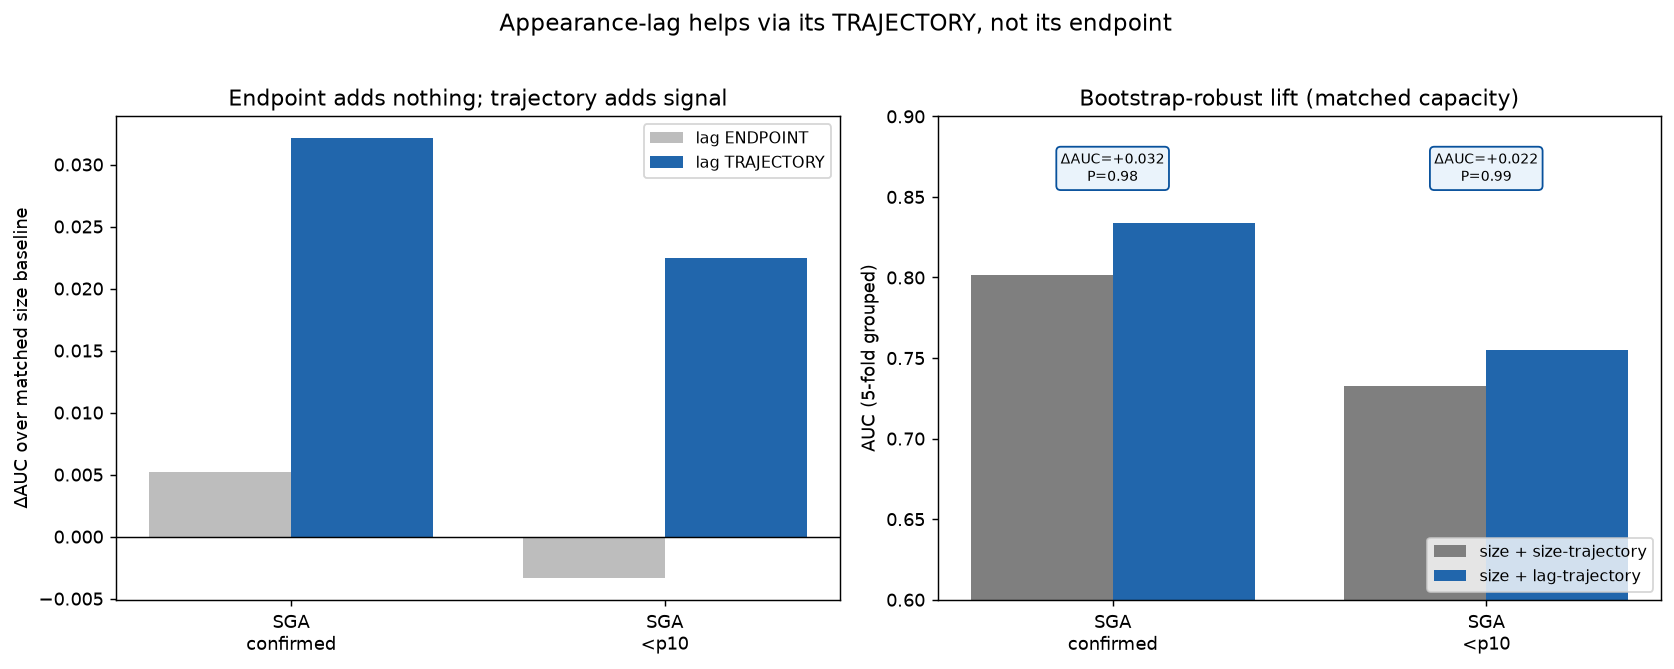

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
# left: endpoint vs trajectory delta
labels=["SGA\nconfirmed","SGA\n<p10"]
endp=[endpoint_delta(sga_conf)[1]-endpoint_delta(sga_conf)[0], endpoint_delta(sga_p10)[1]-endpoint_delta(sga_p10)[0]]
traj_d=[R_conf["dmean"], R_p10["dmean"]]
x=np.arange(2); w=0.38
ax[0].bar(x-w/2,endp,w,label="lag ENDPOINT",color="#bdbdbd")
ax[0].bar(x+w/2,traj_d,w,label="lag TRAJECTORY",color="#2166ac")
ax[0].axhline(0,color="k",lw=.8); ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_ylabel("ΔAUC over matched size baseline"); ax[0].legend(fontsize=9)
ax[0].set_title("Endpoint adds nothing; trajectory adds signal")
# right: AUC bars with bootstrap CI
base=[R_conf["base"],R_p10["base"]]; full=[R_conf["full"],R_p10["full"]]
ax[1].bar(x-w/2,base,w,label="size + size-trajectory",color="#7f7f7f")
ax[1].bar(x+w/2,full,w,label="size + lag-trajectory",color="#2166ac")
ax[1].set_ylim(0.6,0.9); ax[1].set_xticks(x); ax[1].set_xticklabels(labels); ax[1].set_ylabel("AUC (5-fold grouped)")
for xi,R in zip(x,[R_conf,R_p10]):
    ax[1].text(xi,0.86,f"ΔAUC={R['dmean']:+.3f}\nP={R['P']:.2f}",ha="center",fontsize=8,
               bbox=dict(boxstyle="round",fc="#eaf3fb",ec="#08519c"))
ax[1].legend(fontsize=9,loc="lower right"); ax[1].set_title("Bootstrap-robust lift (matched capacity)")
fig.suptitle("Appearance-lag helps via its TRAJECTORY, not its endpoint",fontsize=13,y=1.02)
fig.tight_layout(); plt.show()

## 7.  The 3-D latent trajectory (interactive)

Each fetus is a path through **GA × lag-axis × size-axis**. Faint lines are individuals; bold lines are group-mean paths; ◆ marks the term endpoint. The confirmed-SGA and SGA<p10 groups drift upward on the lag axis near term.

In [ ]:
low  = np.isfinite(birth) & (birth < 10)
conf = np.isfinite(sga_conf) & (sga_conf == 1)
norm = np.isfinite(birth) & (birth >= 10)
groups = [("SGA (birth pct <10)", low, "#e6550d"),
          ("confirmed-SGA (prenatal)", conf, "#c65b5b"),
          ("normal (>=p10)", norm, "#9e9e9e")]
gagrid = np.arange(20, 39, 1.0)
fig3d = go.Figure()
for lab,mask,c in groups:
    idxs=np.where(mask)[0]; show=idxs if lab!="normal (>=p10)" else idxs[::6]
    lagM=[]; szM=[]
    for i in idxs:
        Lf=Lt[i]
        if Lf<2: continue
        g=GAch[i,:Lf]*36+6; la=traj[i,:Lf,lag_axis]; sa=traj[i,:Lf,size_axis]
        lagM.append(np.interp(gagrid,g,la,np.nan,np.nan)); szM.append(np.interp(gagrid,g,sa,np.nan,np.nan))
        if i in show:
            fig3d.add_trace(go.Scatter3d(x=g,y=la,z=sa,mode="lines",line=dict(color=c,width=1.5),
                                         opacity=0.16,showlegend=False,hoverinfo="skip"))
    ml=np.nanmean(lagM,0); ms=np.nanmean(szM,0)
    fig3d.add_trace(go.Scatter3d(x=gagrid,y=ml,z=ms,mode="lines+markers",line=dict(color=c,width=8),
                                 marker=dict(size=4,color=c),name=f"{lab} (n={len(idxs)})"))
    fig3d.add_trace(go.Scatter3d(x=[gagrid[-1]],y=[ml[-1]],z=[ms[-1]],mode="markers",
                                 marker=dict(size=8,color=c,symbol="diamond",line=dict(color="black",width=2)),
                                 showlegend=False,hoverinfo="skip"))
fig3d.update_layout(title="Latent trajectories: GA × lag-axis (z%d) × size-axis (z%d)" % (lag_axis,size_axis),
                    scene=dict(xaxis_title="gestational age (wk)",yaxis_title="lag axis",zaxis_title="size axis"),
                    width=950,height=720)
fig3d.write_html(f"{IMG}/lag_latent_trajectory_3d.html", include_plotlyjs="cdn")
display(HTML(fig3d.to_html(include_plotlyjs="cdn", full_html=False)))

## 8.  Conclusion

- A fetus is a **path through the 8-D GRU-VAE latent**; the lag axis (data-identified) carries appearance-maturity, orthogonal to the size axis.
- The lag **endpoint** adds ~nothing to SGA discrimination over size (ΔAUC ≈ 0) — consistent with lag being non-predictive of final *size*.
- The lag **trajectory** — how appearance-maturity evolves relative to size over gestation — adds **bootstrap-robust** discrimination over a *matched* size-trajectory baseline: **confirmed-SGA ΔAUC ≈ +0.03 (P≈0.98)**, **SGA<p10 ΔAUC ≈ +0.02 (P≈0.99)**.
- The signal is **modest and concentrated on SGA labels** (not severe-SGA / NICU), and rests on sparse sequences (median 3 biometry + 2 image visits/fetus). It is a size-independent maturation-*dynamics* marker, not a size predictor.